# Template for making figure of PCRglobwb output

In [50]:
import xarray as xr
import glob
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import netCDF4 as nc
from pathlib import Path
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.colors import LogNorm
import pandas as pd




In [51]:
output_folder = "../../model_runs/pcrglobwb/test_shapefile/pcrglobwb_20251217_123110/netcdf"

# Add a pattern to select .nc files
files = sorted(glob.glob(f"{output_folder}/*.nc"))

# Check if any files were found
print("Found files:", files)

# Open all datasets
datasets = [xr.open_dataset(f, engine="netcdf4") for f in files]

Found files: ['../../model_runs/pcrglobwb/test_shapefile/pcrglobwb_20251217_123110/netcdf/discharge_dailyTot_output.nc']


In [52]:
for i, f in enumerate(files, start=1):
    print(i, f)

1 ../../model_runs/pcrglobwb/test_shapefile/pcrglobwb_20251217_123110/netcdf/discharge_dailyTot_output.nc


In [53]:
ds_selected = datasets[0]
print(ds_selected)

<xarray.Dataset> Size: 66MB
Dimensions:    (time: 366, lat: 180, lon: 252)
Coordinates:
  * time       (time) datetime64[ns] 3kB 1959-01-01 1959-01-02 ... 1960-01-01
  * lat        (lat) float32 720B 48.96 48.88 48.79 48.71 ... 34.21 34.12 34.04
  * lon        (lon) float32 1kB 59.04 59.12 59.21 59.29 ... 79.79 79.88 79.96
Data variables:
    discharge  (time, lat, lon) float32 66MB ...
Attributes:
    description:  by Edwin H. Sutanudjaja (contact: e.h.sutanudjaja@uu.nl)
    institution:  Department of Physical Geography, Utrecht University
    title:        PCR-GLOBWB 2 output (not coupled to MODFLOW)


In [54]:
# select variable and time
subset = ds_selected['discharge'].isel(
    time = -1  # Select a specific time if applicable
)


# possible subset selection for logaritmic scaling
subset = subset.where(subset > 1)





No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


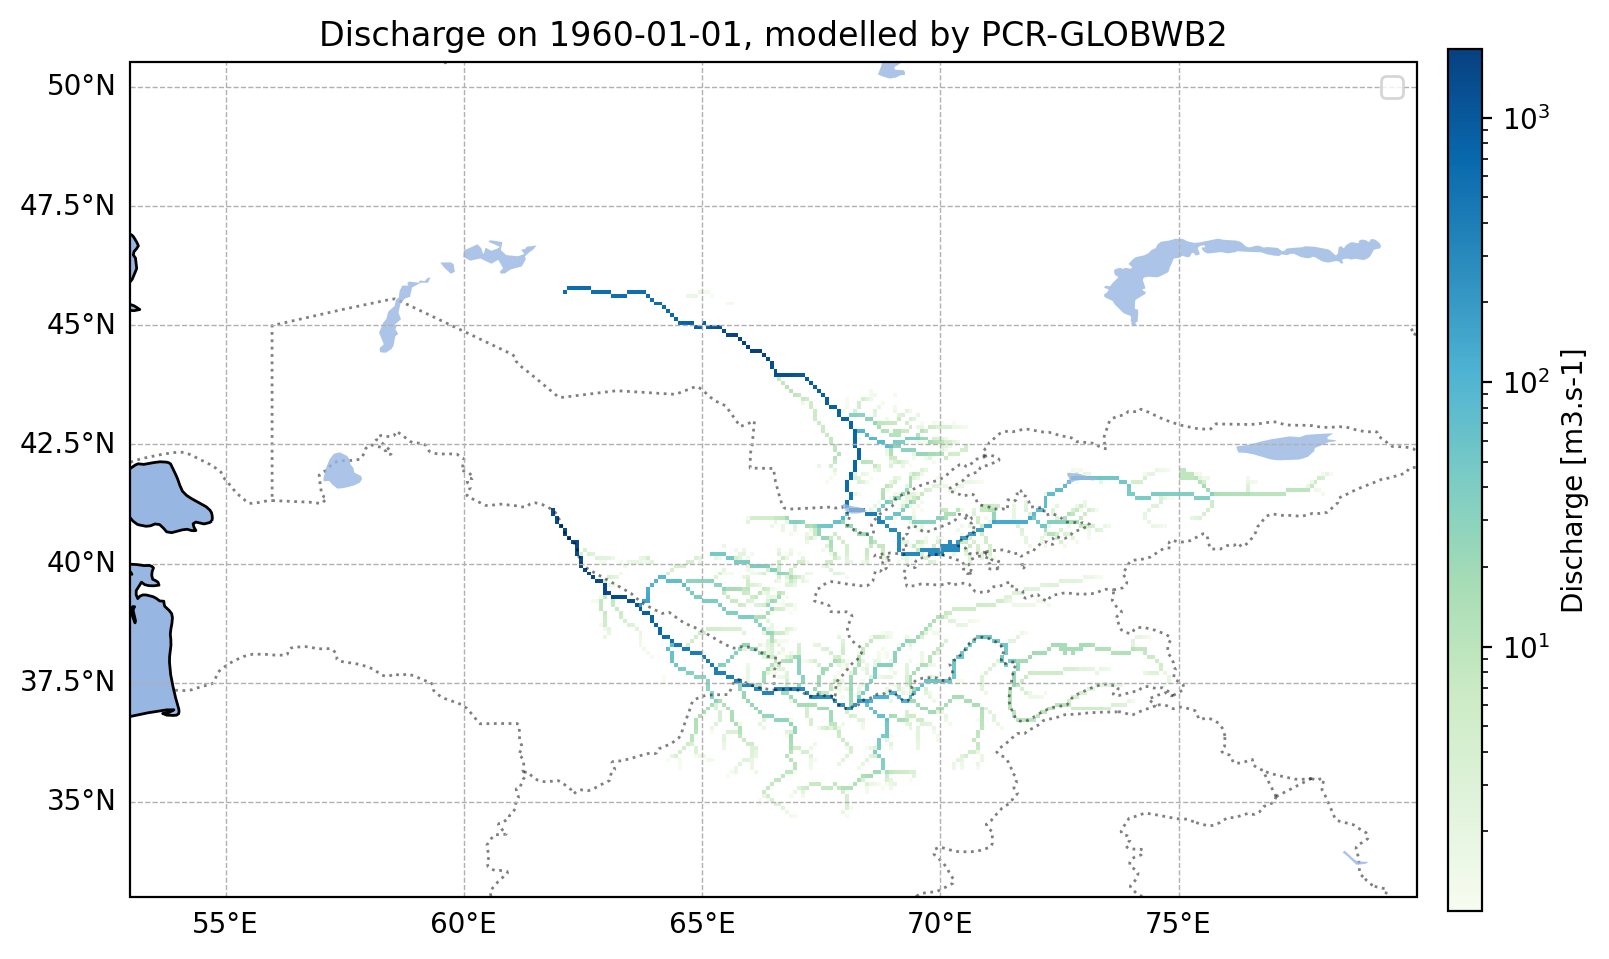

In [ ]:
fig = plt.figure(figsize=(10,8), dpi=200)
ax = fig.add_subplot(111, projection=ccrs.PlateCarree())

# Convert time and name
time_str = pd.to_datetime(subset.time.values).strftime("%Y-%m-%d")
variable_name = subset.standard_name.capitalize()

mappable = subset.plot(
    ax=ax,
    cmap="GnBu",
    norm=LogNorm(vmin=subset.min(), vmax=subset.max()),
    add_colorbar=False,  # prevent xarray from adding a default colorbar
)

# Add colorbar manually
cbar = fig.colorbar(
    mappable,              # <-- THIS is the QuadMesh returned by plot()
    ax=ax,
    orientation="vertical",
    shrink=0.7,
    aspect=25,
    pad=0.02,
    #extend = 'both'
)
cbar.set_label(f"{variable_name} [{subset.units}]")


# Coastlines and other features
ax.add_feature(cfeature.OCEAN, zorder=2)
ax.add_feature(cfeature.BORDERS, linestyle=':',alpha=0.5, zorder=2)
ax.add_feature(cfeature.LAKES, alpha=0.8, zorder=2)
ax.coastlines(zorder=3)

# Set map extent
ax.set_extent([53, 80, 33, 50])

gl = ax.gridlines(draw_labels=True, linestyle="--", linewidth=0.5)
gl.top_labels = False
gl.right_labels = False


# Legend
ax.legend(loc="upper right")



# Dynamic title
title = f"{variable_name} on {time_str}, modelled by PCR-GLOBWB2"

# Title
ax.set_title(title, fontsize=12)




#plt.savefig("PCR_output.png", dpi=300, bbox_inches='tight')
plt.show()






